## Image Features
Earlier we applied various types of image filters. In this notebook, we will learn techniques to extract colour, shapes, lines and templates using computer vision methods

What we will cover in this notebook:
- Image Colour Detection
- Template Matching
- Shape Detection
- Line Detection

### Setup 

In [1]:
import cv2
import numpy as np
import pandas as pda
import matplotlib.pyplot as plt

Let us reuse the `show_image` utility function from previous demonstrations.

In [2]:
# Utility function to display images
def show_image(img, fig_size = None):
    print(img.shape)
    img = img.astype('uint8')

    if fig_size is not None:
        plt.figure(figsize=fig_size)

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

### Colour Detection

Now, let us detect a specific colour object from a sample image. We will use one of the images with different colours.

(258, 320, 3)


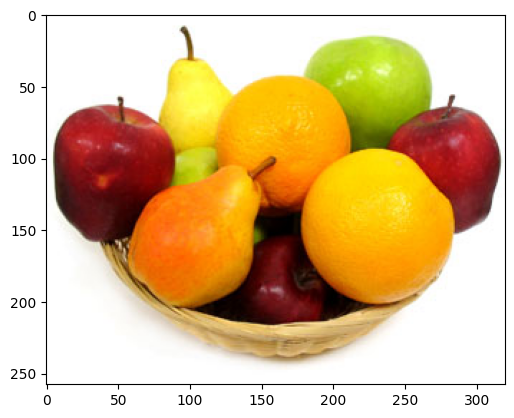

In [4]:
fruit_image = cv2.imread('data/fruit.png')
gray_fruit = cv2.imread('data/gray_fruit.png')
show_image(fruit_image)

(258, 320, 3)


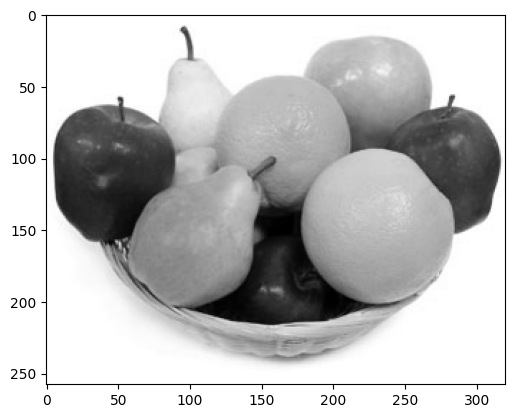

In [5]:
show_image(gray_fruit)

This fruits image is a perfect sample for colour detection task as it has multiple colour objects like red, green, orange, yellow.

Now, let us detect "red" coloured apples from this image and create a "red-coloured" mask to highlight in our sample image. We will use the gray-scale image to superimpose the red coloured mask, so that other colours are grayed out except the red apples.

To do this, we need to first extract the "red colour" from the RGB colour channel by defining the red colour intensity range. We will choose a range that allows limited variation in the non-red channels to account for lighting and noise, while ensuring that the red channel remains dominant.

In [6]:
lowerRange = np.array([0,0,0]) # Colour mask to identify red colour
upperRange = np.array([100,80,255]) # Colour mask to identify red colour (take blue < 100, green <80 and red till 255)

Now, we will create a red coloured mask superimposed with the gray image using `inRange()` from `open-cv` library

(258, 320)


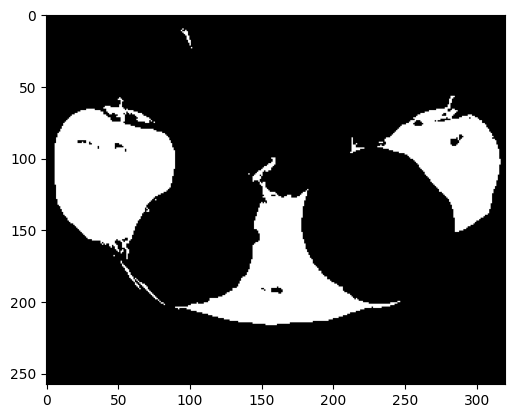

In [7]:
duplicate = fruit_image.copy() # from the coloured image
mask = cv2.inRange(duplicate, lowerRange, upperRange)
show_image(mask)

In [10]:
# Now, let us create a function to apply the colour mask
def apply_colored_mask(mask, img2):
    result = cv2.bitwise_or(duplicate,duplicate, mask= mask)    # contains pixels only in red regions
    masked_image = cv2.bitwise_or(img2, result)                 # overlays red to the image, keeping only red range region
    show_image(masked_image)

(258, 320, 3)


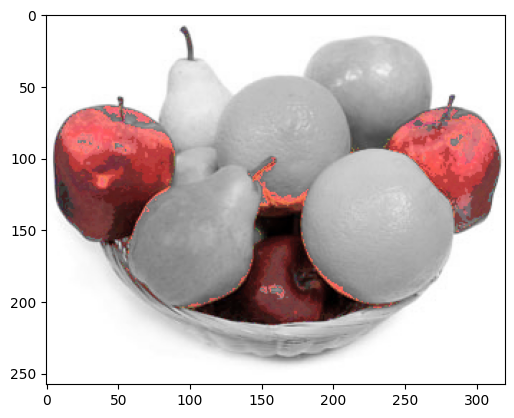

In [11]:
apply_colored_mask(mask, gray_fruit)

### Template Matching
Template matching in computer vision is a technique to find small template images (patterns) within a larger source image by sliding the template across it, calculating similarity metrics (like Sum of Squared Differences or Correlation) at each spot, and identifying regions with the highest (or lowest) scores, useful for object detection and tracking despite challenges with scale/rotation. It works by comparing pixel values, outputting a probability map, and finding peaks (best matches).

Template matching is based on the principle of Normalised Correlation, used for pattern matching and localisation of a specific object of interest within the main image.

In [12]:
import scipy.signal as sp   # for correlation

# Find template 2D
def find_template_2D(template, img):
    c = sp.correlate2d(img, template, mode='same')

    # These y, x coordinates represent the peak. This point needs to be translated to be the top-left corner
    y, x = np.unravel_index(np.argmax(c), c.shape)
    return y - template.shape[0] // 2, x - template.shape[1] // 2

(345, 360)


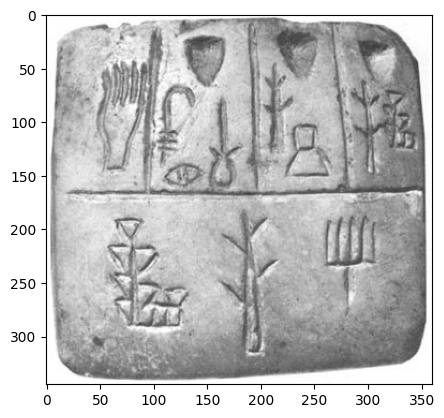

In [13]:
tablet = cv2.imread('data/tablet.png', 0)
show_image(tablet)

(91, 35)


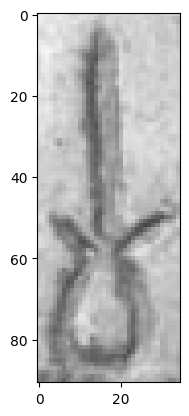

In [14]:
glyph = tablet[74:165, 149:184]
show_image(glyph)

(345, 360, 3)


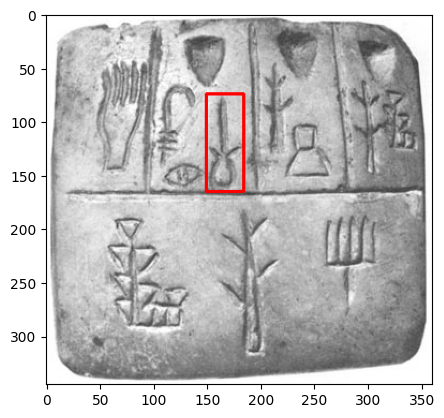

In [15]:
tablet_2 = 1. * tablet - np.mean(tablet)
glyph_2 = 1. * glyph - np.mean(glyph)

y, x = find_template_2D(glyph_2, tablet_2)

tablet_copy = cv2.cvtColor(tablet, code=cv2.COLOR_GRAY2BGR)
cv2.rectangle(tablet_copy, (x, y), (x + glyph.shape[1], y + glyph.shape[0]), (0, 0, 255), thickness=2)
show_image(tablet_copy)

As we can see from this example, we were able to exactly detect selected pattern using our template matching function.

### Line Detection
Now, let us use `open-cv` to perform line detection. Straight Line Detection can be done using [Hough Line Transform Algorithm](https://docs.opencv.org/4.12.0/d9/db0/tutorial_hough_lines.html) using `open-cv`.

(865, 1536, 3)


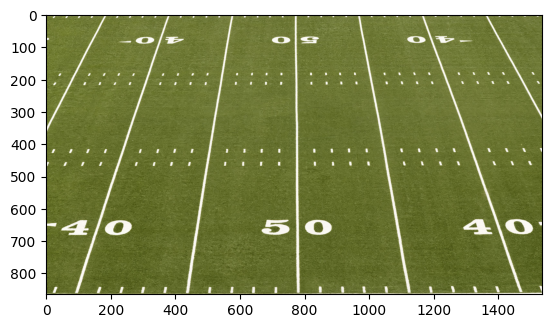

In [16]:
houghLineImage = cv2.imread('data/houghLines.png')
show_image(houghLineImage)

To detect lines and shapes, we need to first apply blurrying filters to remove noisy pixels and smoothen the image. Then use `HoughLinesP()` to detect lines.

`houghlinesp` (Probabilistic Hough Line Transform) is an efficient function that detects line segments in an image, returning their endpoints directly, unlike the standard Hough Transform which returns line parameters $\rho$, $\theta$ and requires more computation to get endpoints

In [ ]:
def line_detector(input_img):
    img = input_img.copy()
    blurred = cv2.GaussianBlur(img,(5,5),0)
    edges = cv2.Canny(blurred,50,150)
    lines = cv2.HoughLinesP(edges, rho = 1, theta = (np.pi/180), threshold = 15, minLineLength = 50, maxLineGap = 10)
    if(lines is not None):
        for i in range(len(lines)):
            x1,y1,x2,y2 = lines[i][0]
            cv2.line(img,(x1,y1),(x2,y2),(255,0,0),3)

        show_image(img)
    else:
        print('No straight line is detected')

(865, 1536)
(92, 1, 4)
(865, 1536, 3)


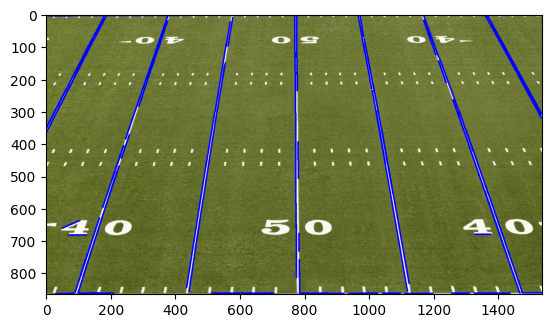

In [21]:
line_detector(houghLineImage)

### Shape Detection
In this section we will see how to leverage CV algorithms and techniques to detect the following basic geometrical shapes like Circle, Square, Rectangle, Triangle.

#### Circle Detection

For circle detection, we will use Hough Circle Transform Algorithm from OpenCV.

(805, 803, 3)


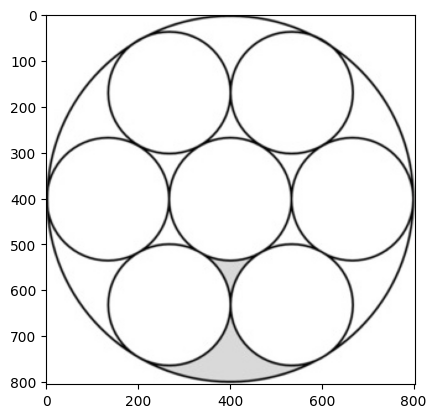

In [22]:
houghCircleImage = cv2.imread('data/houghCircles.png')
show_image(houghCircleImage)

In [ ]:
def circle_detector(input_img, minDist=50, minRadius=100, maxRadius=150):
    img = input_img.copy()
    blurred = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)
    circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT, 1, minDist = minDist, param1 = 50, param2 = 30, minRadius = minRadius, maxRadius = maxRadius)

    circles = np.uint16(np.around(circles))
    for i in circles[0,:]:
        # draw the outer circle
        cv2.circle(img, (i[0], i[1]), i[2], (0,255,0), 5)
        # draw the center of the circle
        # cv2.circle(img,(i[0],i[1]),2,(0,0,255),10)

    return img

(805, 803, 3)


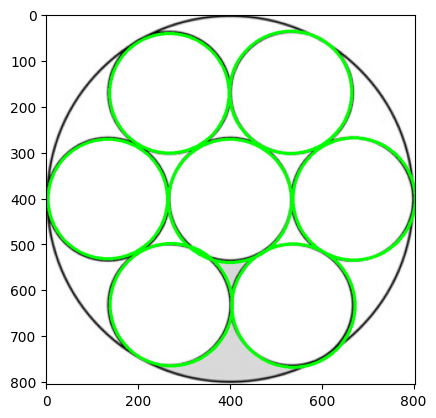

In [24]:
circle_marked_image = circle_detector(houghCircleImage, minDist=50, minRadius=100,maxRadius=150)
show_image(circle_marked_image)

#### Square Detection

(385, 512, 3)


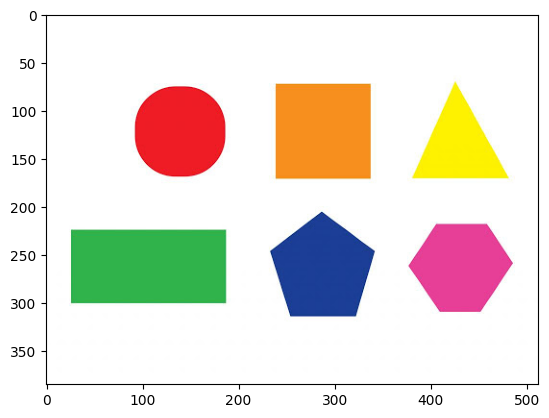

In [25]:
shapesImage = cv2.imread('data/square.png')
show_image(shapesImage)

In [26]:
def square_detector(img):
    img = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,threshold = cv2.threshold(gray, 230, 255,cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.009*cv2.arcLength(cnt, True), True)

        x = approx.ravel()[0]
        y = approx.ravel()[1]

        if len(approx) == 4:
            area = cv2.contourArea(cnt)
            if(area < (0.8 * img.shape[0] * img.shape[1])):

                (x1, y1, w1, h1) = cv2.boundingRect(approx)

                ar = w1 / float(h1)
                # a square will have an aspect ratio that is approximately
                # equal to one, otherwise, the shape is a rectangle
                if ar >= 0.95 and ar <= 1.05:
                    print('Square Detected')
                    cv2.drawContours(img, [approx], 0, (0), 5)
                    cv2.putText(img, "Square", (x-5, y-10), cv2.FONT_HERSHEY_COMPLEX, 1.2, (0,0,255),2)
                    show_image(img)

Square Detected
(385, 512, 3)


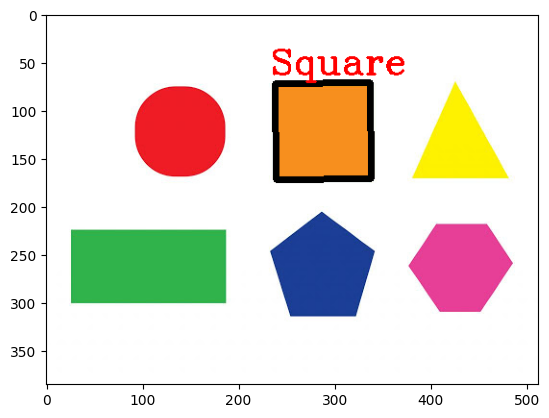

In [27]:
square_detector(shapesImage)

#### Rectangle Detector

In [34]:
def rectangle_detector(img):
    img = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,threshold = cv2.threshold(gray, 230, 255,cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.009*cv2.arcLength(cnt, True), True)

        x = approx.ravel()[0]
        y = approx.ravel()[1]

        if len(approx) == 4:
            area = cv2.contourArea(cnt)
            if(area < (0.8 * img.shape[0] * img.shape[1])):

                (x1, y1, w1, h1) = cv2.boundingRect(approx)

                ar = w1 / float(h1)
                # a rectangle will not have an aspect ratio of one
                if ar < 0.95 or ar > 1.05:
                    print('Rectangle Detected')
                    cv2.drawContours(img, [approx], 0, (0), 5)
                    cv2.putText(img, "Rectangle", (x-5, y-10), cv2.FONT_HERSHEY_COMPLEX, 1.2, (255,0,0),2)
                    show_image(img)

Rectangle Detected
(385, 512, 3)


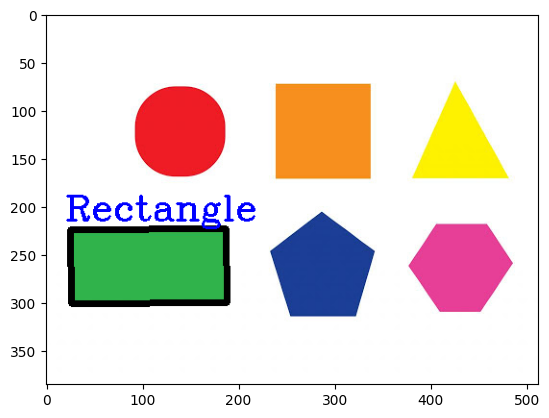

In [35]:
rectangle_detector(shapesImage)

#### Triangle Detector

In [30]:
def triangle_detector(img):
    img = img.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _,threshold = cv2.threshold(gray, 230, 255,cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(threshold, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        approx = cv2.approxPolyDP(cnt, 0.009*cv2.arcLength(cnt, True), True)
        x = approx.ravel()[0]
        y = approx.ravel()[1]

        if len(approx) == 3:
                print('Triangle Detected')
                cv2.drawContours(img, [approx], 0, (0), 5)
                cv2.putText(img, "Triangle", (x-55, y-10), cv2.FONT_HERSHEY_COMPLEX, 1, (0,255,0),2)
                show_image(img)

Triangle Detected
(385, 512, 3)


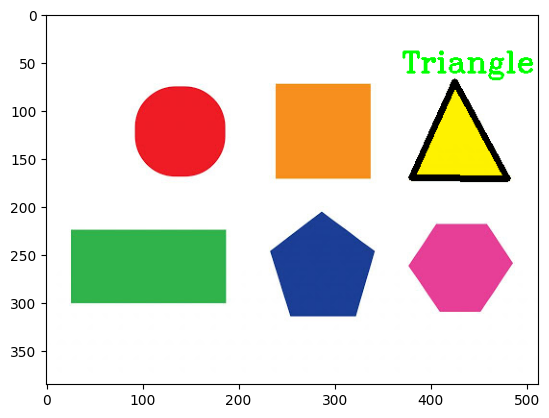

In [31]:
triangle_detector(shapesImage)

This brings us to the end of this notebook. We explored how to detect colours, templates, lines and shapes during image processing. These are essential feature extract steps in conventional computer vision approaches.